# 01 — Data Acquisition

**Project:** Can Search-Trend Data Improve Short-Horizon Macro Nowcasts? A Gradient-Boosting Approach

**Notebook purpose:** Pull all target and predictor series from **FRED** (unemployment rate, initial claims, industrial production, nonfarm payrolls) and **Google Trends** (search-interest indices), align them to a common monthly frequency, and persist a clean merged panel to `data/processed/` for downstream EDA and modeling.

**Data sources (all free, public, no paid license):**
- FRED (Federal Reserve Bank of St. Louis) — https://fred.stlouisfed.org
- Google Trends — https://trends.google.com

---

## 1. Setup

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt

from src.utils import load_config, get_path
from src.data_acquisition import (
    fetch_all_fred_series,
    fetch_google_trends,
    resample_to_monthly,
)

config = load_config('../config.yaml')
config

{'target': {'fred_series': 'UNRATE', 'name': 'unemployment_rate'},
 'fred_predictors': [{'series_id': 'ICSA',
   'name': 'initial_claims',
   'resample': 'mean'},
  {'series_id': 'INDPRO', 'name': 'industrial_production', 'resample': 'last'},
  {'series_id': 'PAYEMS', 'name': 'nonfarm_payrolls', 'resample': 'last'}],
 'google_trends': {'keywords': ['file for unemployment',
   'unemployment office',
   'jobs near me'],
  'geo': 'US',
  'timeframe': '2004-01-01 2024-12-31'},
 'sample': {'start_date': '2004-01-01', 'end_date': '2024-12-31'},
 'modeling': {'n_lags': 3,
  'test_window_months': 60,
  'random_state': 42,
  'xgboost': {'n_estimators': 300,
   'max_depth': 3,
   'learning_rate': 0.05,
   'subsample': 0.8,
   'colsample_bytree': 0.8},
  'arima_order': [1, 0, 1]},
 'paths': {'raw_dir': 'data/raw', 'processed_dir': 'data/processed'}}

## 2. Fetch FRED series

Target: `UNRATE` (civilian unemployment rate). Predictors: `ICSA` (initial jobless claims, weekly), `INDPRO` (industrial production index), `PAYEMS` (nonfarm payrolls).

In [2]:
fred_raw = fetch_all_fred_series(
    target_series=config['target']['fred_series'],
    predictor_configs=config['fred_predictors'],
    start_date=config['sample']['start_date'],
)
fred_raw.tail()

,UNRATE,ICSA,INDPRO,PAYEMS
date,,,,
2026-08-15,NaN,207000.0,NaN,NaN
2026-08-22,NaN,204000.0,NaN,NaN
2026-08-29,NaN,207000.0,NaN,NaN
2026-09-05,NaN,206000.0,NaN,NaN
2026-09-12,NaN,196000.0,NaN,NaN


In [3]:
resample_rules = {
    config['target']['fred_series']: 'last',
    **{cfg['series_id']: cfg['resample'] for cfg in config['fred_predictors']},
}
fred_monthly = resample_to_monthly(fred_raw, resample_rules)
fred_monthly.tail()

,UNRATE,ICSA,INDPRO,PAYEMS
date,,,,
2026-05-31,4.3,211600.0,102.6396,158861.0
2026-06-30,4.2,222500.0,102.8420,158892.0
2026-07-31,4.1,203250.0,103.0454,158913.0
2026-08-31,4.1,206000.0,103.0682,159075.0
2026-09-30,NaN,201000.0,NaN,NaN


## 3. Fetch Google Trends search-interest indices

Weekly indices resampled to monthly means. `pytrends` can rate-limit; the fetch is cached to `data/raw/google_trends.csv` after the first successful run so re-running this notebook does not re-hit the API.

In [4]:
trends_raw = fetch_google_trends(
    keywords=config['google_trends']['keywords'],
    timeframe=config['google_trends']['timeframe'],
    geo=config['google_trends']['geo'],
)
trends_raw.tail()

,file for unemployment,unemployment office,jobs near me
date,,,
2024-08-01,4,8,87
2024-09-01,4,7,84
2024-10-01,4,7,78
2024-11-01,3,7,74
2024-12-01,4,8,71


In [5]:
trends_resample_rules = {kw: 'mean' for kw in trends_raw.columns}
trends_monthly = resample_to_monthly(trends_raw, trends_resample_rules)
trends_monthly.tail()

,file for unemployment,unemployment office,jobs near me
date,,,
2024-08-31,4.0,8.0,87.0
2024-09-30,4.0,7.0,84.0
2024-10-31,4.0,7.0,78.0
2024-11-30,3.0,7.0,74.0
2024-12-31,4.0,8.0,71.0


## 4. Merge into a single monthly panel

In [6]:
panel = fred_monthly.join(trends_monthly, how='inner')
panel = panel.loc[config['sample']['start_date']:config['sample']['end_date']]
print(panel.shape)
panel.tail()

(252, 7)


,UNRATE,ICSA,INDPRO,PAYEMS,file for unemployment,unemployment office,jobs near me
date,,,,,,,
2024-08-31,4.2,230600.0,100.4309,157757.0,4.0,8.0,87.0
2024-09-30,4.1,224500.0,99.8084,157912.0,4.0,7.0,84.0
2024-10-31,4.1,236250.0,99.4695,157945.0,4.0,7.0,78.0
2024-11-30,4.2,219200.0,99.2925,158079.0,3.0,7.0,74.0
2024-12-31,4.1,222750.0,100.3273,158316.0,4.0,8.0,71.0


## 5. Quick sanity plot

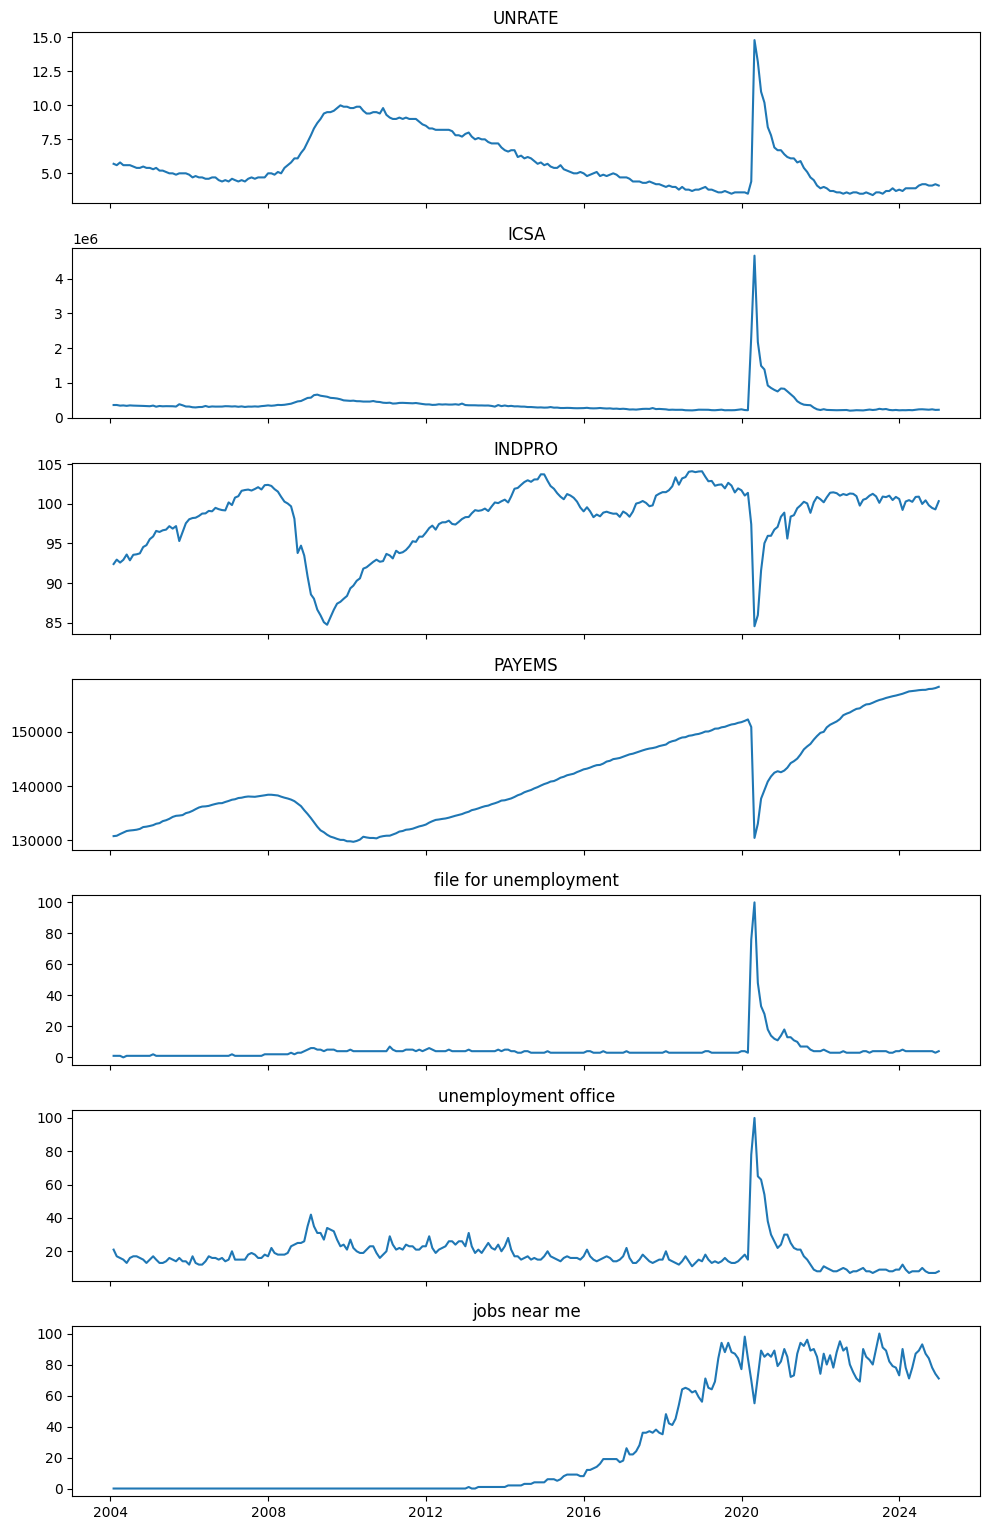

In [7]:
fig, axes = plt.subplots(len(panel.columns), 1, figsize=(10, 2.2 * len(panel.columns)), sharex=True)
for ax, col in zip(axes, panel.columns):
    ax.plot(panel.index, panel[col])
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 6. Persist the processed panel

In [8]:
out_path = get_path(config['paths']['processed_dir'] + '/panel_monthly.csv')
panel.to_csv(out_path)
print(f'Saved merged monthly panel to {out_path}')

Saved merged monthly panel to E:\Research_Projects\Economics_Bulletin\econ-ml-nowcasting\data\processed\panel_monthly.csv


---
## Notebook summary

- Pulled `UNRATE`, `ICSA`, `INDPRO`, `PAYEMS` from FRED and three Google Trends keyword series.
- Aligned all series to month-end frequency using appropriate resampling (mean for flow/weekly variables, last observation for stock/monthly variables).
- Persisted the merged panel to `data/processed/panel_monthly.csv` for use in `02_eda.ipynb`.

**Next notebook:** `02_eda.ipynb` — stationarity, seasonality, and correlation analysis.